## ДЗ №2. Матричные факторизации

#### В этой домашке вам предстоит реализовать некоторые базовые модели матричной факторизации

#### Дата выдачи: 17.02.25

#### Мягкий дедлайн: 02.03.25 23:59 MSK

#### Жесткий дедлайн: 09.03.25 23:59 MSK

В этом задании мы будем работать с классическим для рекоендательных систем датасетом [MovieLens 1M](https://grouplens.org/datasets/movielens/1m/). Датасет содержит рейтинги оценки для 4000 фильмов от 6000 пользователей. Более подробное описание можете найти на странице с датасетом и в README файле

In [ ]:
!wget https://files.grouplens.org/datasets/movielens/ml-1m.zip
!unzip ml-1m.zip
!cat ml-1m/README

--2026-05-30 14:30:50--  https://files.grouplens.org/datasets/movielens/ml-1m.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5917549 (5.6M) [application/zip]
Saving to: ‘ml-1m.zip.1’

ml-1m.zip.1          32%[=====>              ]   1.85M   153KB/s    eta 22s    ^C
Archive:  ml-1m.zip
replace ml-1m/movies.dat? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [1]:
import pandas as pd
import numpy as np
from typing import Union

In [2]:
df = pd.read_csv("ml-1m/ratings.dat", sep='::', names=['user_id', 'item_id', 'rating', 'timestamp'], engine='python')
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')
df.drop('timestamp', axis=1, inplace=True)
df.head()

,user_id,item_id,rating,datetime
0,1,1193,5,2000-12-31 22:12:40
1,1,661,3,2000-12-31 22:35:09
2,1,914,3,2000-12-31 22:32:48
3,1,3408,4,2000-12-31 22:04:35
4,1,2355,5,2001-01-06 23:38:11


In [3]:
value_counts = df['item_id'].value_counts()
filtered_values = value_counts[value_counts > 20].index
df = df[df['item_id'].isin(filtered_values)].copy()

In [4]:
train_end = '2000-12-01'
df_train = df[df['datetime'] < train_end].copy()
df_test = df[df['datetime'] >= train_end].copy()
df_train.shape, df_test.shape

((787420, 4), (207432, 4))

In [5]:
train_users = df_train['user_id'].unique()
train_items = df_train['item_id'].unique()

df_test = df_test[df_test['user_id'].isin(train_users)]
df_test = df_test[df_test['item_id'].isin(train_items)]
df_test.shape

(106471, 4)

In [6]:
from sklearn.preprocessing import LabelEncoder

user_le = LabelEncoder()
item_le = LabelEncoder()

df_train['user_id'] = user_le.fit_transform(df_train['user_id'])
df_train['item_id'] = item_le.fit_transform(df_train['item_id'])

df_test['user_id'] = user_le.transform(df_test['user_id'])
df_test['item_id'] = item_le.transform(df_test['item_id'])

In [7]:
df_train['user_id'].nunique(), df_train['user_id'].max()
df_train['item_id'].nunique(), df_train['item_id'].max()

(3010, np.int64(3009))

##### Задание 1. Напишем функцию, которая превратит датафрейм в матрицу интеракций. В функции df_to_matrix реализуйте функцию, которая принимает датафрейм и возвращает np.array матрицу интеракций. В функции df_to_coo реализуйте функцию, которая принимает датафрейм и возвращает разреженную матрицу интеракций в coo_array формате

In [8]:
df.head()

,user_id,item_id,rating,datetime
0,1,1193,5,2000-12-31 22:12:40
1,1,661,3,2000-12-31 22:35:09
2,1,914,3,2000-12-31 22:32:48
3,1,3408,4,2000-12-31 22:04:35
4,1,2355,5,2001-01-06 23:38:11


In [9]:
from scipy.sparse import coo_array


def df_to_matrix(df: pd.DataFrame) -> np.ndarray:
    row = df["user_id"].values
    col = df["item_id"].values
    data = df["rating"].values
    n_users = np.max(row) + 1
    n_items = np.max(col) + 1
    result = np.zeros((n_users, n_items))
    result[row, col] = data

    return result

In [10]:
interactions = df_to_matrix(df_train)

In [11]:
from scipy.sparse import coo_array

def df_to_coo(df: pd.DataFrame) -> coo_array:
    
    row = df["user_id"].values
    col = df["item_id"].values
    data = df["rating"].values
    n_users = np.max(row) + 1
    n_items = np.max(col) + 1

    return coo_array((data, (row, col)), shape=(n_users, n_items))

In [12]:
coo_interactions = df_to_coo(df_train)

In [13]:
assert (interactions != 0).sum() == df_train.shape[0]
assert interactions[0, 2994] == 3
assert interactions[2369, 1203] == 5
assert interactions[1557, 459] == 3
assert np.allclose(coo_interactions.toarray(), interactions)

##### Задание 2.1. Рассмотрим [SVD](https://en.wikipedia.org/wiki/Singular_value_decomposition). Возьмите готовую реализуцию алгоритма из numpy.linalg или из scipy.linalg и примените алгоритм к матрицам интеракций, полученным в первом задании. Для работы со sparse матрицей обычная реализация svd не подойдет и нужно будет воспользоваться scipy.sparse.linalg.svds. Вам нужно разложить матрицу интеракций на 3 матрицы U, S, V, а затем перемножить их и восстановить изначальную матрицу. При полном разложении исходная матрица должна восстанавливаться максимально хорошо

In [14]:
from numpy import ndarray
from scipy.sparse.linalg import svds


def make_svd(interractions: Union[np.ndarray, coo_array], n_singular_values: int = -1):
    # функция должна работать и для полной матрицы и для sparse матрицы(вам поможет isinstance).
    # если n_singular_values = -1, то берем все сингулярные числа для полной матрицы
    # и все кроме одного сингулярного числа для coo-матрицы(иначе scipy.sparse.linalg.svds не будет работать)
    U, S, V = None, None, None
    if isinstance(interractions, np.ndarray):
        U, S, V = np.linalg.svd(interractions, full_matrices=False)
        if n_singular_values != -1:
            n = n_singular_values
            return U[:, :n], np.diag(S[:n]), V[:n, :]
    else:
        if n_singular_values == -1:
            U, S, V = svds(interractions, k=min(interractions.shape) - 1)
        else:
            U, S, V = svds(interractions, k=n_singular_values)
        order = np.argsort(S)[::-1]
        U, S, V = U[:, order], S[order], V[order, :]
        
    return U, np.diag(S), V

In [15]:
U, S, V = make_svd(interactions)
assert np.allclose(U @ S @ V, interactions)

In [16]:
U1, S1, V1 = make_svd(interactions, 10)
U, S, V = make_svd(coo_interactions, 10)
assert np.allclose(U1 @ S1 @ V1, U @ S @ V)

##### Задание 2.2. Теперь попробуем сделать рекомендации с помощью SVD. Мы научились восстанавливать исходную матрицу с помощью разложения, теперь же мы хотим порекомендовать пользователю айтемы, которые будут для него максимально релевантны(в восстановленной матрице у них будет самый высокий скор). Для каждого пользователя нужно будет найти индексы айтемов, которые имеют максимальный скор. При этом стоит обратить внимание, что мы не хотим рекомендовать пользователю айтемы, с которыми он уже взаимодействовал

In [17]:
def make_svd_recommendations(interractions: Union[np.ndarray, coo_array], n_singular_values: int = -1, top_k: int = 100):
    # Возвращает матрицу вида n_users, top_k, то есть для каждого пользователя возвращаем индексы 
    # top_k самых релевантный айтемов среди тех с которыми он еще не взаимодействовал

    U, S, V = make_svd(interractions, n_singular_values)
    intercat_pred = U @ S @ V
    recommendations = None
    if isinstance(interractions, np.ndarray):
        already_watch = np.argwhere(interractions != 0)
        rows, cols = already_watch[:, 0], already_watch[:, 1]
        intercat_pred[rows, cols] = -np.inf
        recommendations = np.argsort(intercat_pred, axis=1)[:, -top_k:]
    else:
        rows = interractions.row
        cols = interractions.col
        intercat_pred[rows, cols] = -np.inf
        recommendations = np.argsort(intercat_pred, axis=1)[:, -top_k:][:, ::-1]
    return recommendations #shape ~ [n_users, top_k]

In [18]:
recs = make_svd_recommendations(interactions, -1, 100)
assert recs.shape == (interactions.shape[0], 100)

##### Задание 2.3. Теперь давайте посмотрим как будет зависеть качетво рекомендаций, от количества сингулярных чисел, которые мы возьмем в SVD разложении. Переберите n_singular_values из списка [1, 10, 50, 200, 1000] и посмотрите как будет изменяться метрика NDCG на тестовом датасете для таких рекомендаций и как будет меняться время вычисления. Для каждого графики зависимости метрики NDCG от n_singular_values и времени работы алгоритма от n_singular_values(Время работы будет меняться только для sparse-матрицы, стоит запускать алгоритм именно для нее)

In [19]:
from matplotlib import pyplot as plt
from sklearn.metrics import ndcg_score
import time

def plot_graphs(interractions: Union[np.ndarray, coo_array], test_matrix, top_k: int = 100):
    ndcg_results = []
    time_calculations = []
    y_train = df_train["rating"].to_numpy()
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    singular_values = [1, 10, 50, 200, 1000]
    for n_singular_values in singular_values:
        time_start = time.time()
        U, S, V = make_svd(interractions, n_singular_values)
        preds = U @ S @ V
        time_full = time.time() - time_start
        time_calculations.append(time_full)
        curr_ndcg = ndcg_score(test_matrix, preds, k=top_k)
        ndcg_results.append(curr_ndcg)

    ax[0].plot(singular_values, ndcg_results, marker="o")
    ax[0].set_title("NDCG vs n_singular_values")
    ax[1].plot(singular_values, time_calculations, marker="o")
    ax[1].set_title("Time calculate vs n_singular_values")
    plt.show()

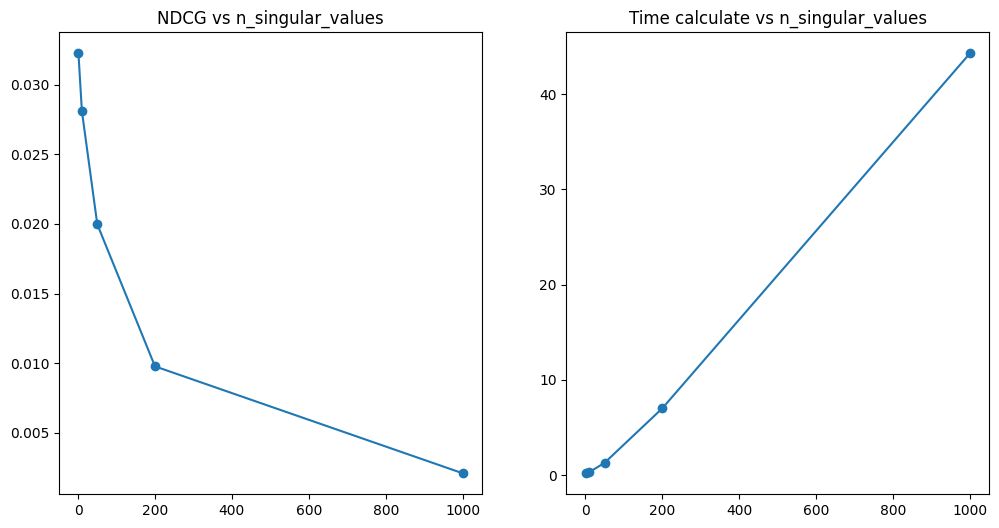

In [20]:
test_matrix = np.zeros(interactions.shape)
test_matrix[df_test['user_id'], df_test['item_id']] = df_test['rating']
plot_graphs(coo_interactions, test_matrix)

##### Задание 3.1. Перейдем к [ALS](http://yifanhu.net/PUB/cf.pdf). Возьмем реализацию iALS из библиотеки [implicit](https://benfred.github.io/implicit/api/models/cpu/als.html). Обучите ALS на нашем датасете, сделайте top_k рекомендации для юзеров из тестового датасета, и сравните метрики ALS с метриками, которые получились в SVD. Попробуйте перебрать гиперпараметры и найдите оптимальное число факторов, коэффициент alpha и коэффициент регуляризации.

In [ ]:
from scipy.sparse import csr_matrix
import implicit

def make_als_recommendations(
    interractions: Union[np.ndarray, coo_array], 
    top_k: int = 100, 
    n_factors: int = 100,
    alpha: float = 1.0,
    regularization: float = 0.01,
):
    sparse_interractions = csr_matrix(interractions)
    conf_data = (sparse_interractions * alpha).astype('float32')
    model = implicit.als.AlternatingLeastSquares(
        factors=n_factors, 
        regularization=regularization, 
        iterations=20, 
        random_state=42
    )

    model.fit(conf_data)
    full_scores = model.user_factors @ model.item_factors.T
    recommendations, _ = model.recommend(
        np.arange(conf_data.shape[0]), 
        conf_data, 
        N=top_k, 
        filter_already_liked_items=True
    )
    
    return recommendations, full_scores

/home/anton/Desktop/yandex_ml_otbor/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
recs, preds = make_als_recommendations(interactions, alpha=40)
assert recs.shape == (interactions.shape[0], 100)

/home/anton/Desktop/yandex_ml_otbor/.venv/lib/python3.12/site-packages/implicit/cpu/als.py:96: RuntimeWarning: OpenBLAS is configured to use 20 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|██████████| 20/20 [00:01<00:00, 18.12it/s]


In [23]:
U, S, V = make_svd(coo_interactions, n_singular_values=20)
preds_svd = U @ S @ V
score_svd = ndcg_score(test_matrix, preds_svd, k=100)
print(f"SVD NDCG: {score_svd:.4f}")

score_als = ndcg_score(test_matrix, preds, k=100)
print(f"ALS NDCG: {score_als:.4f}")

SVD NDCG: 0.0249
ALS NDCG: 0.0244


In [24]:
import pandas as pd

factors_list = [20, 50, 100, 200]
alphas_list = [1, 10, 30]
best_ndcg = -1
best_params = {}
results_data = []


for f in factors_list:
    for a in alphas_list:
        recs, scores = make_als_recommendations(
            coo_interactions, 
            n_factors=f, 
            alpha=a, 
            regularization=0.1
        )
        
        curr_ndcg = ndcg_score(test_matrix, scores, k=100)
        results_data.append({'factors': f, 'alpha': a, 'ndcg': curr_ndcg})
        
        if curr_ndcg > best_ndcg:
            best_ndcg = curr_ndcg
            best_params = {'factors': f, 'alpha': a}

print(f"Лучший NDCG: {best_ndcg:.4f} при параметрах {best_params}")

100%|██████████| 20/20 [00:52<00:00,  2.64s/it]


Лучший NDCG: 0.0261 при параметрах {'factors': 20, 'alpha': 10}


##### Задание 3.2. Сделайте объяснение рекомендаций для нескольких юзеров(als.explain). Воспользуйтесь файлом movies.dat чтобы перейти от индексов фильмов к их названием

In [25]:
movies = pd.read_csv("ml-1m/movies.dat", sep='::', names=['item_id', 'title', 'genres'], engine='python', encoding='latin-1')
id_to_title = {}

for _, row in movies.iterrows():
    if row["item_id"] in item_le.classes_:
        internal_id = item_le.transform([row['item_id']])[0]
        id_to_title[internal_id] = row["title"]
        
best_alpha = 10
best_factors = 20
conf_data = (csr_matrix(coo_interactions) * best_alpha).astype('float32')
best_model = implicit.als.AlternatingLeastSquares(
    factors=best_factors, 
    regularization=0.1, 
    iterations=20, 
    random_state=42
)
best_model.fit(conf_data)

100%|██████████| 20/20 [00:00<00:00, 22.05it/s]


In [28]:
def explain_for_user(user_id, model, conf_matrix, n_explain=3):
    rec_ids, _ = model.recommend(user_id, conf_matrix[user_id], N=1, filter_already_liked_items=True)
    target_item = rec_ids[0]
    _, contributions, _ = model.explain(user_id, conf_matrix, target_item)
    print(f"Пользователю с id: {user_id} Рекомендуем: {id_to_title.get(target_item, 'Неизвестно')}")
    print("потому что он смотрел")
    for item_idx, weight in contributions[:n_explain]:
        print(f"{id_to_title.get(item_idx, 'Неизвестно')} (вклад: {weight:.3f})")
    print("\n")

for uid in [4, 5, 6]:
    explain_for_user(uid, best_model, conf_data)

Пользователю с id: 4 Рекомендуем: Close Encounters of the Third Kind (1977)
потому что он смотрел
2001: A Space Odyssey (1968) (вклад: 0.064)
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1963) (вклад: 0.061)
To Kill a Mockingbird (1962) (вклад: 0.058)


Пользователю с id: 5 Рекомендуем: American Pie (1999)
потому что он смотрел
Bowfinger (1999) (вклад: 0.068)
Austin Powers: The Spy Who Shagged Me (1999) (вклад: 0.057)
13th Warrior, The (1999) (вклад: 0.053)


Пользователю с id: 6 Рекомендуем: Star Wars: Episode VI - Return of the Jedi (1983)
потому что он смотрел
Star Wars: Episode IV - A New Hope (1977) (вклад: 0.221)
Back to the Future (1985) (вклад: 0.168)
Jurassic Park (1993) (вклад: 0.167)




##### Задание 4. До этого мы работали с рейтингами, но как обсуждалось на лекции, implicit ALS отлично работает и с implicit фидбэком. Давайте попробуем преобразовать наш датасет(трейн и тест) следующим образом

1. Бинаризуем все рейтинги(заменим любую интеракцию пользователя на 1)
2. Заменим на 1 только рейтинги 4 и 5, а рейтинг ниже 4 заменим на 0
3. Заменим на 1 только рейтинги 4 и 5, а рейтинг ниже 4 заменим на -1
4. Заменим на 1 только рейтинги 4 и 5, а рейтинг ниже 4 заменим на -1 и добавим сглаживание по времени. То есть чем дальше была интеракция от максимальной даты трейна, тем с меньшим весом мы будем ее учитывать(например можно интеракции за последний месяц брать в исходном виде, и с каждым месяцем в прошлое умножать их на какой-нибудь коэффициент меньший 1). Таким образом более старые интеракции пользователя будут вносить меньший вклад в его интересы
5. Придумайте свой вариант(опционально)

Для каждой полученной матрицы обучите iALS и SVD и сравните их результаты между собой(преобразовывать нужно только обучающую выборку, тестовую оставляем неизменной)

In [29]:
def evaluate_transform(df_transformed, name):
    coo_train = df_to_coo(df_transformed)
    U, S, V = make_svd(coo_train, n_singular_values=20)
    preds_svd = U @ S @ V
    score_svd = ndcg_score(test_matrix, preds_svd, k=100)
    _, preds_als = make_als_recommendations(coo_train, n_factors=20, alpha=10)
    score_als = ndcg_score(test_matrix, preds_als, k=100) 
    print(name)
    print(f"SVD NDCG: {score_svd} | ALS NDCG: {score_als}\n")
    return score_svd, score_als

In [30]:
max_date = df_train['datetime'].max()
df_1 = df_train.copy()
df_1['rating'] = 1
evaluate_transform(df_1, "любая интеракция пользователя 1")

df_2 = df_train.copy()
df_2['rating'] = df_2['rating'].apply(lambda x: 1 if x >= 4 else 0)
evaluate_transform(df_2, "Заменим на 1 только рейтинги 4 и 5, а рейтинг ниже 4 заменим на 0")

df_3 = df_train.copy()
df_3['rating'] = df_3['rating'].apply(lambda x: 1 if x >= 4 else -1)
evaluate_transform(df_3, "Заменим на 1 только рейтинги 4 и 5, а рейтинг ниже 4 заменим на -1")

df_4 = df_train.copy()
df_4['rating'] = df_4['rating'].apply(lambda x: 1 if x >= 4 else -1)
days_diff = (max_date - df_4['datetime']).dt.days
months_diff = days_diff / 30.0
decay_factor = 0.95 ** months_diff 
df_4['rating'] = df_4['rating'] * decay_factor
evaluate_transform(df_4, "Заменим на 1 только рейтинги 4 и 5, а рейтинг ниже 4 заменим на -1 и добавим сглаживание по времени")

100%|██████████| 20/20 [00:00<00:00, 22.60it/s]


любая интеракция пользователя 1
SVD NDCG: 0.023508981530444936 | ALS NDCG: 0.024546830612585675



100%|██████████| 20/20 [00:00<00:00, 22.99it/s]


Заменим на 1 только рейтинги 4 и 5, а рейтинг ниже 4 заменим на 0
SVD NDCG: 0.026379111569664077 | ALS NDCG: 0.026103665327881324



100%|██████████| 20/20 [00:00<00:00, 22.16it/s]


Заменим на 1 только рейтинги 4 и 5, а рейтинг ниже 4 заменим на -1
SVD NDCG: 0.028760100527299104 | ALS NDCG: 0.030196060417338966



100%|██████████| 20/20 [00:00<00:00, 22.03it/s]


Заменим на 1 только рейтинги 4 и 5, а рейтинг ниже 4 заменим на -1 и добавим сглаживание по времени
SVD NDCG: 0.028981082132675088 | ALS NDCG: 0.02997296529830351



(0.028981082132675088, 0.02997296529830351)

##### Задание 5. iALS на numpy/torch. Давайте реализуем алгоритм iALS на нумпае или торче. Требуется реализовать алгорит, описанный в 4 части [статьи](http://yifanhu.net/PUB/cf.pdf). Обратите внимания на все оптимизации, которые они описывают в статье, чтобы сократить лишние вычисления. Hint: метрики у вашего алгоритма должны быть сравнимы с метриками ALS из библиотеки implicit

In [39]:
import numpy as np
from scipy.sparse import csr_matrix, coo_matrix
from typing import Union
from tqdm.auto import tqdm 

class iALS:
    def __init__(self, n_factors: int = 100, alpha: float = 1.0, reg_coef: float = 0.01):
        self.n_factors = n_factors
        self.alpha = alpha
        self.reg_coef = reg_coef
        self.X = None 
        self.Y = None 
        self.train_interactions = None

    def fit(self, interactions: Union[np.ndarray, coo_matrix, csr_matrix], n_iterations: int = 10):
        if isinstance(interactions, np.ndarray):
            R_user = csr_matrix(interactions)
        else:
            R_user = interactions.tocsr()
            
        R_item = R_user.tocsc()
        n_users, n_items = R_user.shape
        self.train_interactions = R_user
        np.random.seed(42)
        self.X = np.random.rand(n_users, self.n_factors) * 0.01
        self.Y = np.random.rand(n_items, self.n_factors) * 0.01
        reg_matrix = self.reg_coef * np.eye(self.n_factors)

        for iteration in tqdm(range(n_iterations)):
            YTy = self.Y.T @ self.Y + reg_matrix
            for u in range(n_users):
                start, end = R_user.indptr[u], R_user.indptr[u+1]
                if start == end: 
                    self.X[u] = 0.0
                    continue
                item_idx = R_user.indices[start:end]
                rui = R_user.data[start:end]
                Y_u = self.Y[item_idx]
                C_u_minus_I = self.alpha * rui
                C_u = 1.0 + C_u_minus_I
                A_u = YTy + (Y_u * C_u_minus_I[:, np.newaxis]).T @ Y_u
                b_u = Y_u.T @ C_u
                self.X[u] = np.linalg.solve(A_u, b_u)
            XTx = self.X.T @ self.X + reg_matrix
            
            for i in range(n_items):
                start, end = R_item.indptr[i], R_item.indptr[i+1]
                if start == end:
                    self.Y[i] = 0.0
                    continue
                
                user_idx = R_item.indices[start:end]
                rui = R_item.data[start:end]
                X_i = self.X[user_idx]
                C_i_minus_I = self.alpha * rui
                C_i = 1.0 + C_i_minus_I
                A_i = XTx + (X_i * C_i_minus_I[:, np.newaxis]).T @ X_i
                b_i = X_i.T @ C_i
                self.Y[i] = np.linalg.solve(A_i, b_i)

    def predict(self, top_k: int = 100):
        # возвращает top-k айтемов для каждого юзера(айтемы с которыми юзер взаимодействовал не должны попасть в рекомендации)
        preds = self.X @ self.Y.T
        train_coo = self.train_interactions.tocoo()
        preds[train_coo.row, train_coo.col] = -1e9
        predicts = np.argsort(preds, axis=1)[:, -top_k:][:, ::-1]
        return predicts, preds

In [40]:
my_ials = iALS(n_factors=20, alpha=10.0, reg_coef=0.1)
my_ials.fit(coo_interactions, n_iterations=20)
recs_custom, scores_custom = my_ials.predict(top_k=100)
custom_ndcg = ndcg_score(test_matrix, scores_custom, k=100)
print(f"Свой iALS (NumPy) NDCG: {custom_ndcg:.4f}")

100%|██████████| 20/20 [00:07<00:00,  2.70it/s]


Свой iALS (NumPy) NDCG: 0.0467
